# 05b — Archives (cellules retirées du notebook principal)

**Date : 7 juillet 2026 — retirées du `05b_Portefeuille_Membre_MathSpec.ipynb` (état source : commit `a5b14d4`).**

⚠️ **Ce notebook n'est PAS exécutable seul** : les cellules dépendent de l'état du 05b
(`df`, `wf_ret`, `cal`, `select_topK`, …). Les **outputs sont figés** — ce sont ceux du dernier
run validé du 05b.

**Pourquoi ces cellules ont été retirées.** Le calcul du rendement du portefeuille se fait
désormais **uniquement en parts** (méthode du maître de recherche : `nbr^k` constants entre
coupes, NAV continue — §6 du 05b, spécifiée dans `NOTE_NAV_PORTEFEUILLE_EN_PARTS.md`).
L'ancienne écriture « Σ w·cumprod par bloc + concaténation » est **mathématiquement équivalente**
(prouvé : max |Δ rendement quotidien| ~ 1e-16, voir la cellule « preuve » ci-dessous et ses
outputs), mais on ne garde qu'une seule écriture. Sont archivés ici :
1. l'**ancien §6** — `run_strategy` (modes `fixed`/`drift`) + la démonstration du bug des poids
   figés trouvé par Alice ($t$ 1,14 → 0,94) ;
2. les anciens markdown du **§10** d'origine ;
3. l'**ancien moteur semestriel** `run_strategy_6m` (§9) ;
4. la **preuve d'équivalence** ancien-moteur vs parts (tableau par paires identiques).

## 1. L'ancien §6 : combinaison Σ w·cumprod (figé vs dérive)

## 6. La combinaison : buy-and-hold (commune aux deux critères)
« Copier et **tenir** » laisse les poids **dériver** avec la performance ; les figer reviendrait à
rebalancer chaque jour (faux) :
$$\mathrm{NAV}_k(t)=\prod_{s\le t}(1+r_{m_k}(s)),\quad N(t)=\sum_k w_k\,\mathrm{NAV}_k(t),\quad
r_{\text{strat}}(t)=\frac{N(t)}{N(t-1)}-1.$$

In [27]:
def run_strategy(K, mode, years=range(2015, 2026), combine="drift", critere="ir"):
    parts = []
    for Y in years:
        sel = select_topK(Y, K, critere=critere)
        if not sel:
            continue
        if mode == "equal":
            w = np.ones(len(sel)) / len(sel)
        else:                                             # "score" = poids proportionnels au score du critère
            sc = np.array([s for s, _ in sel])
            w = sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)
        idx = cal[cal.year == (Y + 1)]
        if len(idx) == 0:
            continue
        R = pd.DataFrame({bid: wf_ret[bid].reindex(idx).fillna(0.0) for _, bid in sel})
        if combine == "fixed":                       # ANCIEN : poids figés = rebalancement quotidien
            parts.append((R * w).sum(axis=1))
        else:                                         # DRIFT : poids qui dérivent (buy-and-hold)
            navk = (1 + R).cumprod()
            navc = (navk * w).sum(axis=1)
            ry = navc / navc.shift(1) - 1
            ry.iloc[0] = navc.iloc[0] - 1
            parts.append(ry)
    return pd.concat(parts).sort_index()

def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: ((1 + r[r.index.year == y]).prod() - 1) - ((1 + b[r.index.year == y]).prod() - 1)
                      for y in sorted(set(r.index.year))})

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

def _ligne(r):
    e = eval_yearly(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_moyen"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

# les 4 séries de sélection IR (calculées une fois)
r_fix_eq = run_strategy(4, "equal", combine="fixed", critere="ir")
r_dr_eq  = run_strategy(4, "equal", combine="drift", critere="ir")
r_fix_ir = run_strategy(4, "score", combine="fixed", critere="ir")
r_dr_ir  = run_strategy(4, "score", combine="drift", critere="ir")
print("séries stratégie prêtes")

séries stratégie prêtes


In [28]:
# La combinaison figée SURESTIME : top-4 sélection IR, figé vs dérive
pd.DataFrame({
    "top-4 sél IR (1/K) — figé":   eval_yearly(r_fix_eq),
    "top-4 sél IR (1/K) — dérive": eval_yearly(r_dr_eq),
}).T[["exces_moyen", "t", "gagnantes"]].round(3)

,exces_moyen,t,gagnantes
top-4 sél IR (1/K) — figé,0.036491,1.141628,7/11
top-4 sél IR (1/K) — dérive,0.031021,0.943191,7/11


**Lecture.** Les poids figés **surestiment** (rebalancement fantôme) : le $t$ passe de $1{,}14$
(figé) à $0{,}94$ (dérive). On garde la dérive partout.

## 2. Les markdown d'origine du §10 « écrit en parts » (devenu le §6 du 05b)

## 10. La même combinaison, écrite en parts (formalisation du maître de recherche)
Chaque membre $k$ = un **fonds** dont le prix de part est $\mathrm{NAV}^k(t)=\prod_{s\le t}(1+r_k(s))$,
calculé **une fois sur tout le calendrier** (plate hors fenêtre active $=$ cash). Le portefeuille ne
suit qu'une chose : ses **nombres de parts** $\mathrm{nbr}^k$, constants entre deux rebalancements.
- **Au rebalancement** $t_j^R$ (fin de journée) : richesse disponible
  $\mathrm{NAV}^{\mathrm{avl}} = \sum_k \mathrm{nbr}^k_{\text{anciens}}\,\mathrm{NAV}^k(t_j^R)$, puis
  $\mathrm{nbr}^k = w_j^k\,\mathrm{NAV}^{\mathrm{avl}} / \mathrm{NAV}^k(t_j^R)$.
- **Entre deux coupes** : $\mathrm{NAV}(t)=\sum_k \mathrm{nbr}^k\,\mathrm{NAV}^k(t)$, série **continue**
  (base 100), et $r_{\text{strat}}(t)=\mathrm{NAV}(t)/\mathrm{NAV}(t-1)-1$.
- **Autofinancement** : $\sum_k \mathrm{nbr}^k_{\text{nouveaux}}\,\mathrm{NAV}^k(t_j^R)=\mathrm{NAV}^{\mathrm{avl}}$
  $\Rightarrow$ aucun saut à la coupe.

Mêmes sélections, mêmes poids initiaux, même buy-and-hold que §6–§9 — on **prouve** ci-dessous que
les rendements sont identiques.

**Lecture.**
- L'écriture en parts et la combinaison « dérive » des §6–§9 sont **le même calcul** :
  max $|\Delta| \sim 10^{-16}$ (bruit machine) sur toutes les configurations $\Rightarrow$ **tous les
  chiffres et conclusions des §6–§9 restent valides tels quels**.
- L'apport du formalisme : la **NAV continue** (base 100) est l'objet naturel — chaque coupe est
  autofinancée (on compte avec les anciennes parts, on redéploie aux nouveaux poids), et **tout**
  rendement (jour, semestre, année, fenêtre $D_H$ quelconque) est un ratio de deux points de cette
  courbe.
- La moyenne à poids **figés** du §6 reste, dans ce langage, l'erreur « parts non constantes » :
  elle revend les gagnants chaque soir sans le dire.

## 3. L'ancien moteur semestriel du §9 (`run_strategy_6m`, cellule complète d'origine)

In [35]:
# --- Moteur SEMESTRIEL : coupe 30/06 & 31/12, on tient le semestre suivant ---
def classement_a_date(d, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """classement_a_fin, mais à une DATE de coupe quelconque (point-in-time strict <= d)."""
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        n_trades = int((wf_traded[bid] <= d).sum()); n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252); t = score * np.sqrt(n_days / 252)
        else:
            ab = alpha_beta(rr); score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, score=score))
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=["bioguide_id", "score"]))

cuts = [pd.Timestamp(y, m, dd) for y in range(2015, 2026) for (m, dd) in [(6, 30), (12, 31)]]
next_bound = lambda d: pd.Timestamp(d.year, 12, 31) if d.month == 6 else pd.Timestamp(d.year + 1, 6, 30)
clsmt6_ir = {d: classement_a_date(d, critere="ir")        for d in cuts}
clsmt6_ap = {d: classement_a_date(d, critere="appraisal") for d in cuts}

def run_strategy_6m(K, mode="equal", critere="ir"):
    cache = clsmt6_ir if critere == "ir" else clsmt6_ap
    parts = []
    for d in cuts:
        c = cache[d]
        if len(c) == 0:
            continue
        sel = list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
        if mode == "equal":
            w = np.ones(len(sel)) / len(sel)
        else:
            sc = np.array([s for s, _ in sel]); w = sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)
        idx = cal[(cal > d) & (cal <= next_bound(d))]
        if len(idx) == 0:
            continue
        R = pd.DataFrame({bid: wf_ret[bid].reindex(idx).fillna(0.0) for _, bid in sel})
        navk = (1 + R).cumprod(); navc = (navk * w).sum(axis=1)
        ry = navc / navc.shift(1) - 1; ry.iloc[0] = navc.iloc[0] - 1
        parts.append(ry)
    return pd.concat(parts).sort_index()

def eval_sem(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    sem = r.index.year.values * 2 + (r.index.month.values > 6).astype(int)
    e = pd.Series({s: ((1 + r[sem == s]).prod() - 1) - ((1 + b[sem == s]).prod() - 1) for s in sorted(set(sem))})
    n = len(e); ir = e.mean() / e.std(ddof=1)
    return dict(exces_an=2 * e.mean(), t=ir * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}", n=n)

def _ligne6(r):
    e = eval_sem(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_an"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

r_6m_ir = run_strategy_6m(4, "equal", "ir")
r_6m_ap = run_strategy_6m(4, "equal", "appraisal")
print(f"moteur 6 mois prêt | {len(cuts)} coupes | n semestres : IR={eval_sem(r_6m_ir)['n']}, appr={eval_sem(r_6m_ap)['n']}")

moteur 6 mois prêt | 22 coupes | n semestres : IR=22, appr=22


## 4. La preuve d'équivalence : ancien moteur vs NAV en parts (asserts + tableau par paires)

In [40]:
# PREUVE : la NAV en parts = une autre ÉCRITURE du même calcul -> les lignes du tableau, par paires IDENTIQUES
paires = {
    "top-4 sél IR (1/K) — annuel":       (r_dr_eq, strategie_en_parts(4, "equal", "ir"),              _ligne),
    "top-4 sél appraisal — annuel":      (r_ap_eq, strategie_en_parts(4, "equal", "appraisal"),       _ligne),
    "top-4 sél IR — 6 mois":             (r_6m_ir, strategie_en_parts(4, "equal", "ir", "6m"),        _ligne6),
    "top-4 sél appraisal — 6 mois":      (r_6m_ap, strategie_en_parts(4, "equal", "appraisal", "6m"), _ligne6),
}
rows = {}
for nom_s, (ancien, det, ligne_fn) in paires.items():
    assert ancien.index.equals(det["r"].index)
    assert np.allclose(ancien.values, det["r"].values, rtol=0, atol=1e-10)   # identiques au bruit machine près
    rows[f"{nom_s} — moteur §6/§9"] = ligne_fn(ancien)
    rows[f"{nom_s} — en parts §10"] = ligne_fn(det["r"])
assert np.allclose(r_dr_ir.values, strategie_en_parts(4, "score", "ir")["r"].values, rtol=0, atol=1e-10)  # idem ∝score
det4 = strategie_en_parts(4, "equal", "ir")                # réutilisé par les 2 cellules suivantes
assert np.allclose(det4["nav"], 100 * (1 + det4["r"]).cumprod(), rtol=0, atol=1e-9)
print("asserts passés (max|Δ rendement quotidien| ~ 1e-16) : chaque paire de lignes est identique")
pd.DataFrame(rows).T.round(3)

asserts passés (max|Δ rendement quotidien| ~ 1e-16) : chaque paire de lignes est identique


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
top-4 sél IR (1/K) — annuel — moteur §6/§9,0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
top-4 sél IR (1/K) — annuel — en parts §10,0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
top-4 sél appraisal — annuel — moteur §6/§9,-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
top-4 sél appraisal — annuel — en parts §10,-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
top-4 sél IR — 6 mois — moteur §6/§9,0.00432,0.137703,12/22,1.237727,-0.024558,-0.638371
top-4 sél IR — 6 mois — en parts §10,0.00432,0.137703,12/22,1.237727,-0.024558,-0.638371
top-4 sél appraisal — 6 mois — moteur §6/§9,-0.050248,-2.000941,8/22,1.047842,-0.050651,-1.481435
top-4 sél appraisal — 6 mois — en parts §10,-0.050248,-2.000941,8/22,1.047842,-0.050651,-1.481435


## 5. La sélection du nombre K en découpage IS/OS (section retirée du notebook principal)

**Retirée le 7 juillet 2026** (état source : commit `9ceeeee`). C'était la dernière section du 05b
(numérotée §11 puis §10). Elle testait si le choix du nombre de membres à copier ($K$) est
*apprenable* : à chaque coupe, le passé de stratégie est découpé en IS (75 %, sert à choisir $K$)
et OS (25 %, sert à juger le choix). Conclusion : le meilleur $K$ passé ne prédit pas le meilleur
$K$ futur ($t$ 1,58 → 1,29, rangs OS mi-tableau, $\rho$ instable) — « combien copier » n'est pas
apprenable. Expliquée en détail dans `NOTE_CHOIX_K_IS_OS.md` (frise + schémas conservés).

⚠️ **Non exécutable ici** — dépend de l'état du 05b (`R_K_ir`, `R_K_ap`, `score_ir`, `score_appr`,
`select_topK`, `_ligne`, …). Outputs figés du dernier run validé.

## 10. Choisir $K$ avec un vrai découpage IS/OS (qui grandit avec le temps)
Le §8 choisit $K^*(Y)=\arg\max_K \mathrm{score}$ sur **tout** le passé — le même échantillon sert à
choisir et à juger, aucune validation. Ici, à chaque coupe fin-$Y$, on coupe le passé de stratégie
disponible en deux :
$$\mathrm{IS} = \text{premiers } 75\,\%,\qquad \mathrm{OS} = \text{derniers } 25\,\%\ (\ge 63\ \text{jours de bourse}),$$
$$K_{\mathrm{IS}}(Y)=\arg\max_K\;\mathrm{score}_{\text{crit}}\big(\text{strat-}K\big|_{\mathrm{IS}}\big),$$
et l'**OS ne choisit jamais** : on joue $K_{\mathrm{IS}}$ en $Y{+}1$, l'OS sert uniquement de
**diagnostic** — le $K$ élu sur l'IS était-il bon sur la suite qu'il n'a pas vue ? Le split grandit
tout seul : fin-2016, 189 j IS / 63 j OS (le plancher mord là, pile) ; fin-2023, $\sim$6 ans / 2 ans.
⚠️ Pour $K \ge n_{\text{sig}}$, les stratégies-$K$ sont **identiques** (le top-$K$ prend tout) →
scores exactement ex-aequo : les rangs sont donnés **sur les valeurs distinctes** (« $d/D$ »),
« — » quand tout coïncide (coupes $\le$ 2019 surtout).

In [ ]:
# §10 — moteur IS/OS : split 75/25 du passé de stratégie à chaque coupe ; l'OS ne choisit JAMAIS
assert all(RK[K].index.equals(R_K_ir[4].index) for RK in (R_K_ir, R_K_ap) for K in KS)  # calendrier commun

def k_is_os(RbyK, score):
    parts, rows, sc_rows = [], [], []
    for Y in range(2015, 2026):
        if Y == 2015:
            k_is, extra = 4, {}                                    # aucun historique -> défaut, comme §8
        else:
            H = {K: RbyK[K].loc[:pd.Timestamp(f"{Y}-12-31")] for K in KS}
            n = len(H[4]); n_os = max(int(round(0.25 * n)), 63)    # OS = derniers 25 %, plancher 63 j
            # .round(9) : les K structurellement identiques (K >= n_sig) doivent rester EX-AEQUO exacts —
            # le moteur en parts porte un bruit ~1e-16 dépendant du chemin de richesse, qu'on efface ici
            sc_is = pd.Series({K: score(H[K].iloc[:n - n_os]) for K in KS}).round(9)
            sc_os = pd.Series({K: score(H[K].iloc[n - n_os:]) for K in KS}).round(9)
            k_is = min(K for K in KS if sc_is[K] == sc_is.max())   # tie-break min K, comme §8
            sc_rows += [dict(coupe=Y, K=K, sc_IS=sc_is[K], sc_OS=sc_os[K]) for K in KS]
            extra = dict(fin_IS=H[4].index[n - n_os - 1], deb_OS=H[4].index[n - n_os],
                         fin_OS=H[4].index[-1], n_IS=n - n_os, n_OS=n_os,
                         K_OS=min(K for K in KS if sc_os[K] == sc_os.max()),
                         rang_OS=sc_os.rank(method="dense", ascending=False)[k_is],  # rang sur valeurs DISTINCTES
                         K_dist_IS=sc_is.nunique(), K_dist_OS=sc_os.nunique())
        ry = RbyK[k_is][RbyK[k_is].index.year == Y + 1]            # on JOUE K_IS en Y+1
        b = r_spy.reindex(ry.index).fillna(0.0)
        rows.append(dict(annee_tenue=Y + 1, K_IS=k_is,
                         exces_realise=((1 + ry).prod() - 1) - ((1 + b).prod() - 1), **extra))
        parts.append(ry)
    return pd.concat(parts).sort_index(), pd.DataFrame(rows), pd.DataFrame(sc_rows)

r_isos_ir, chemin_isos_ir, scores_isos_ir = k_is_os(R_K_ir, score_ir)    # sél IR   -> jugée par l'IR
r_isos_ap, chemin_isos_ap, scores_isos_ap = k_is_os(R_K_ap, score_appr)  # sél appr -> jugée par l'appraisal
print(f"IS/OS prêt | 10 splits + défaut 2016 | 1re coupe : IS={int(chemin_isos_ir.n_IS.iloc[1])} j / OS={int(chemin_isos_ir.n_OS.iloc[1])} j")

IS/OS prêt | 10 splits + défaut 2016 | 1re coupe : IS=189 j / OS=63 j


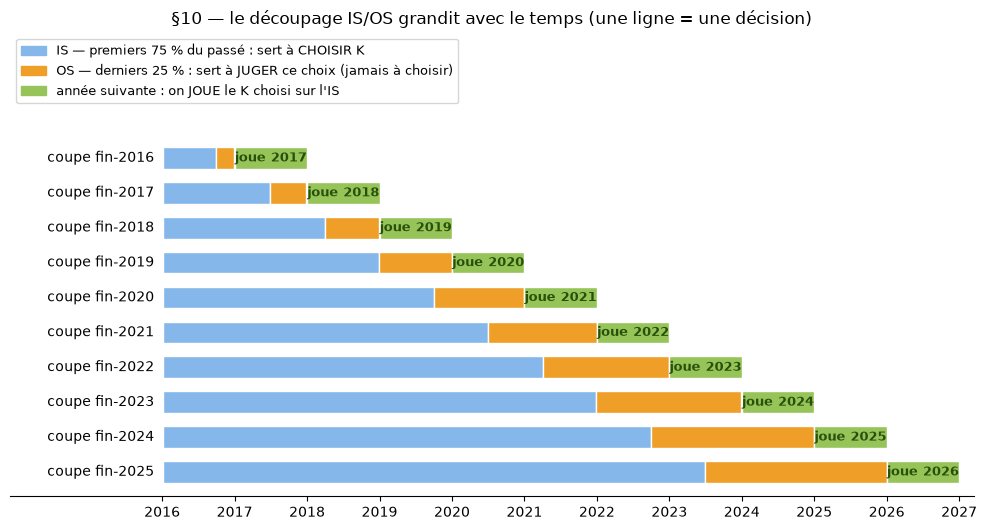

In [ ]:
# FRISE : le découpage de chaque décision, aux bornes réelles du moteur (IS bleu, OS orange, année jouée vert)
import matplotlib.patches as mpatches
ch = chemin_isos_ir.dropna(subset=["fin_IS"])          # la décision fin-2015 (K=4 défaut) n'a pas de split
deb = pd.Timestamp("2016-01-04")
an = lambda t: t.year + t.dayofyear / 366
fig, ax = plt.subplots(figsize=(10, 5.4))
for i, row in enumerate(ch.itertuples()):
    y = len(ch) - i
    a, b = an(row.fin_IS), an(row.fin_OS)
    ax.barh(y, a - an(deb), left=an(deb), height=0.62, color="#85B7EB", edgecolor="white")
    ax.barh(y, b - a, left=a, height=0.62, color="#EF9F27", edgecolor="white")
    ax.barh(y, 1.0, left=row.annee_tenue, height=0.62, color="#97C459", edgecolor="white")
    ax.text(an(deb) - 0.12, y, f"coupe fin-{row.annee_tenue - 1}", ha="right", va="center", fontsize=10)
    ax.text(row.annee_tenue + 0.5, y, f"joue {row.annee_tenue}", ha="center", va="center",
            fontsize=9, color="#27500A", weight="bold")
ax.set_yticks([]); ax.set_xlim(2013.9, 2027.2); ax.set_xticks(range(2016, 2028))
ax.set_ylim(0.3, len(ch) + 3.6)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color="#85B7EB", label="IS — premiers 75 % du passé : sert à CHOISIR K"),
    mpatches.Patch(color="#EF9F27", label="OS — derniers 25 % : sert à JUGER ce choix (jamais à choisir)"),
    mpatches.Patch(color="#97C459", label="année suivante : on JOUE le K choisi sur l'IS"),
], loc="upper left", fontsize=9)
ax.set_title("§10 — le découpage IS/OS grandit avec le temps (une ligne = une décision)")
plt.tight_layout(); plt.show()

In [ ]:
# TABLE CHEMIN : bornes du split (communes aux 2 critères) + K_IS / rang OS / K_OS / excès / ρ(IS,OS)
fr = lambda x: f"{x:+.2f}".replace("-", "−").replace(".", ",")
def _rho(sc):                                                     # Spearman = Pearson sur rangs (sans scipy)
    return {Y: (np.nan if g.sc_IS.nunique() < 2 or g.sc_OS.nunique() < 2
                else g.sc_IS.rank().corr(g.sc_OS.rank())) for Y, g in sc.groupby("coupe")}
def _bloc(ch, sc, tag):
    t, rho = ch.set_index("annee_tenue"), _rho(sc)
    return pd.DataFrame({f"K_IS ({tag})": t.K_IS,
        f"rang OS ({tag})": ["—" if pd.isna(d) else f"{d:.0f}/{D:.0f}" for d, D in zip(t.rang_OS, t.K_dist_OS)],
        f"K_OS ({tag})":    ["—" if pd.isna(k) else f"{k:.0f}" for k in t.K_OS],
        f"excès ({tag})":   t.exces_realise.map(pct),
        f"ρ ({tag})":       ["—" if pd.isna(rho.get(y - 1, np.nan)) else fr(rho[y - 1]) for y in t.index]})
t11 = chemin_isos_ir.set_index("annee_tenue")
bornes = pd.DataFrame({
    "fin IS": ["—" if pd.isna(x) else str(x.date()) for x in t11.fin_IS],
    "OS":     ["—" if pd.isna(a) else f"{a.date()} → {b.date()}" for a, b in zip(t11.deb_OS, t11.fin_OS)],
    "n_OS":   ["—" if pd.isna(x) else f"{x:.0f}" for x in t11.n_OS]}, index=t11.index)
tab11 = pd.concat([bornes, _bloc(chemin_isos_ir, scores_isos_ir, "IR"),
                   _bloc(chemin_isos_ap, scores_isos_ap, "appr")], axis=1)
tab11.index.name = "année tenue"; tab11

,fin IS,OS,n_OS,K_IS (IR),rang OS (IR),K_OS (IR),excès (IR),ρ (IR),K_IS (appr),rang OS (appr),K_OS (appr),excès (appr),ρ (appr)
année tenue,,,,,,,,,,,,,
2016,—,—,—,4,—,—,"−4,2%",—,4,—,—,"−9,6%",—
2017,2016-09-30,2016-10-03 → 2016-12-30,63,4,1/1,4,"+8,5%",—,4,1/1,4,"+9,7%",—
2018,2017-06-30,2017-07-03 → 2017-12-29,126,4,1/1,4,"−1,4%",—,4,1/1,4,"+2,8%",—
2019,2018-04-03,2018-04-04 → 2018-12-31,188,4,1/1,4,"+7,6%",—,4,1/1,4,"−4,4%",—
2020,2018-12-31,2019-01-02 → 2019-12-31,252,4,1/2,4,"+15,9%",—,4,3/4,7,"−2,5%",—
2021,2019-10-02,2019-10-03 → 2020-12-31,315,5,4/5,4,"−8,8%","−0,55",7,3/8,11,"−6,7%","+0,74"
2022,2020-07-02,2020-07-06 → 2021-12-31,378,8,12/16,11,"−13,1%","+0,56",11,17/17,5,"−3,7%","−0,76"
2023,2021-04-05,2021-04-06 → 2022-12-30,440,10,10/16,18,"+12,2%","+0,25",7,11/17,20,"+6,2%","+0,48"
2024,2021-12-29,2021-12-30 → 2023-12-29,503,18,7/16,12,"+4,4%","+0,58",20,12/17,8,"+1,0%","−0,00"


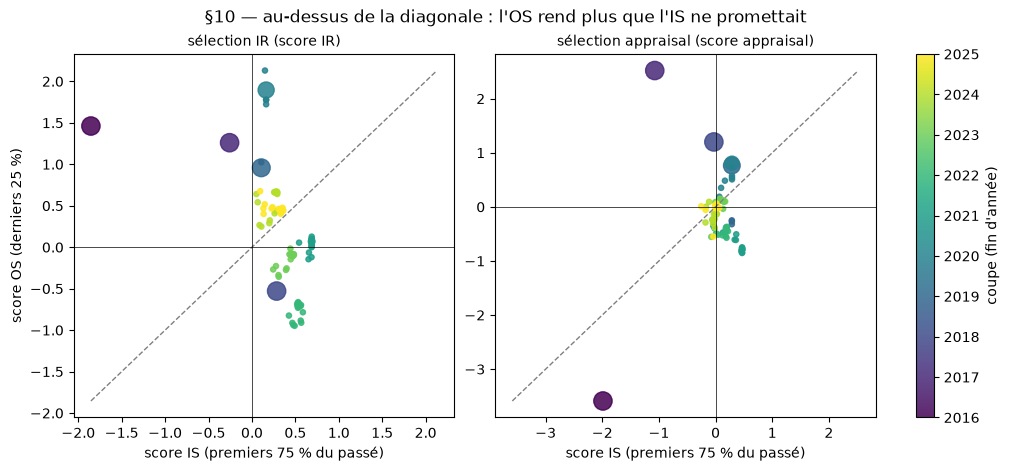

In [ ]:
# FIGURE : le score IS prédit-il le score OS ? (1 point = 1 K × 1 coupe ; gros point = K ex-aequo)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), layout="constrained")
for ax, nom_p, sc in [(axes[0], "sélection IR (score IR)", scores_isos_ir),
                      (axes[1], "sélection appraisal (score appraisal)", scores_isos_ap)]:
    pts = sc.groupby(["coupe", "sc_IS", "sc_OS"], as_index=False).agg(nK=("K", "size"))
    im = ax.scatter(pts.sc_IS, pts.sc_OS, c=pts.coupe, cmap="viridis", s=14 + 10 * (pts.nK - 1), alpha=0.85)
    lim = [min(pts.sc_IS.min(), pts.sc_OS.min()), max(pts.sc_IS.max(), pts.sc_OS.max())]
    ax.plot(lim, lim, color="gray", ls="--", lw=1)
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("score IS (premiers 75 % du passé)"); ax.set_title(nom_p, fontsize=10)
axes[0].set_ylabel("score OS (derniers 25 %)")
fig.colorbar(im, ax=axes, label="coupe (fin d'année)")
fig.suptitle("§10 — au-dessus de la diagonale : l'OS rend plus que l'IS ne promettait")
plt.show()

In [ ]:
# K=4 fixe ∥ K walk-forward §8 (choisi sur TOUT le passé) ∥ K IS/OS §10 (choisi sur 75 % du passé)
pd.DataFrame({
    "K=4 fixe (sél IR)":            _ligne(r_dr_eq),
    "K wf §8 (sél IR)":             _ligne(r_wfK_eq),
    "K IS/OS §10 (sél IR)":         _ligne(r_isos_ir),
    "K=4 fixe (sél appraisal)":     _ligne(r_ap_eq),
    "K wf §8 (sél appraisal)":      _ligne(r_wfK_ap),
    "K IS/OS §10 (sél appraisal)":  _ligne(r_isos_ap),
}).T.round(3)

,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR),0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
K wf §8 (sél IR),0.040673,1.58412,7/11,1.16856,0.011487,0.445576
K IS/OS §10 (sél IR),0.036171,1.287597,7/11,1.185433,0.004761,0.16168
K=4 fixe (sél appraisal),-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
K wf §8 (sél appraisal),-0.009955,-0.541885,5/11,0.973503,-0.005792,-0.289887
K IS/OS §10 (sél appraisal),-0.010965,-0.640591,4/11,0.988416,-0.00819,-0.377796


**Lecture.**
- **Le $K$ élu sur l'IS est rarement confirmé par l'OS.** Hors coupes dégénérées ($\le$ 2019, « — »/« 1/1 »), son rang OS est mi-tableau ou pire — sél IR : 4/5, 12/16, 10/16, 7/16, 2/10, 10/14 ; sél appraisal jusqu'à **17/17** (dernier) à la coupe 2021. Et le $K$ gagnant de l'OS change presque chaque coupe (4, 11, 18, 12, 13, 4).
- **$\rho(\text{score IS}, \text{score OS})$ n'a pas de signe stable** (IR : $-0{,}55$ à $+0{,}63$ ; appraisal : $-0{,}76$ à $+0{,}74$) : le score passé d'un $K$ ne prédit pas son score sur la suite. (Prudence : 17 stratégies-$K$ emboîtées quasi colinéaires, OS courts et coupes non indépendantes → pas de p-value légitime ; c'est un faisceau d'indices, pas un test.)
- **Le prix de la validation** : côté IR, $t = 1{,}58$ (K-wf §8, $K$ choisi sur tout le passé) $\to$ **$1{,}29$** quand le choix n'utilise que l'IS — une partie du gain du §8 était l'écho de l'échantillon qui a servi au choix. Côté appraisal, l'excès reste négatif.
- Verdict inchangé et renforcé : aucun $K$, aucune méthode de choix (fixe, tout-le-passé, IS/OS) ne franchit le seuil — « combien copier » n'est **pas apprenable** sur ces données.